In [1]:
import numpy as np
import matplotlib.pyplot as plt

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Computes scaled dot-product attention.
    Q, K: (..., seq_q, d_k)
    V: (..., seq_k, d_v)
    """
    d_k = Q.shape[-1]


    # S = QK^T / sqrt(d_k)
    scores = np.matmul(Q, K.swapaxes(-2, -1)) / np.sqrt(d_k)


    if mask is not None:
        scores = np.where(mask == 0, -1e9, scores)


    exp_scores = np.exp(scores - np.max(scores, axis=-1, keepdims=True))
    weights = exp_scores / np.sum(exp_scores, axis=-1, keepdims=True)


    output = np.matmul(weights, V)

    return output, weights


np.random.seed(42)
d_k, d_v, seq = 64, 64, 6
Q = np.random.randn(seq, d_k)
K = np.random.randn(seq, d_k)
V = np.random.randn(seq, d_v)
out, w = scaled_dot_product_attention(Q, K, V)
print(f"Output shape: {out.shape}")
print(f"Weights sum: {w.sum(axis=-1)}")

Output shape: (6, 64)
Weights sum: [1. 1. 1. 1. 1. 1.]


In [ ]:
Q1: Pourquoi le scaling par $1/\sqrt{d_k}$ est-il nécessaire ?
Sans ce facteur, pour de grandes dimensions $d_k$, le produit scalaire $QK^T$ peut prendre des valeurs très élevées. Cela pousse la fonction softmax dans des régions où le gradient est extrêmement faible (saturation), ce qui bloque l'apprentissage (vanishing gradients).
Q2: Que représente sémantiquement $A[i, j]$ ?
La valeur $A[i, j]$ représente le score d'attention (ou poids) que le jeton (token) à la position $i$ accorde au jeton à la position $j$. C'est l'importance relative de l'information stockée en $j$ pour répondre au besoin de $i$.
Q3: Support du batch dimension (Bonus):
L'utilisation de np.matmul et swapaxes(-2, -1) dans mon code ci-dessus gère déjà nativement les dimensions de batch grâce au broadcasting de NumPy.
Q4: Complexité computationnelle ?
La complexité est de $\mathcal{O}(n^2 \cdot d)$ où $n$ est la longueur de la séquence et $d$ la dimension du modèle. Ce n'est pas efficace pour des séquences très longues (croissance quadratique).

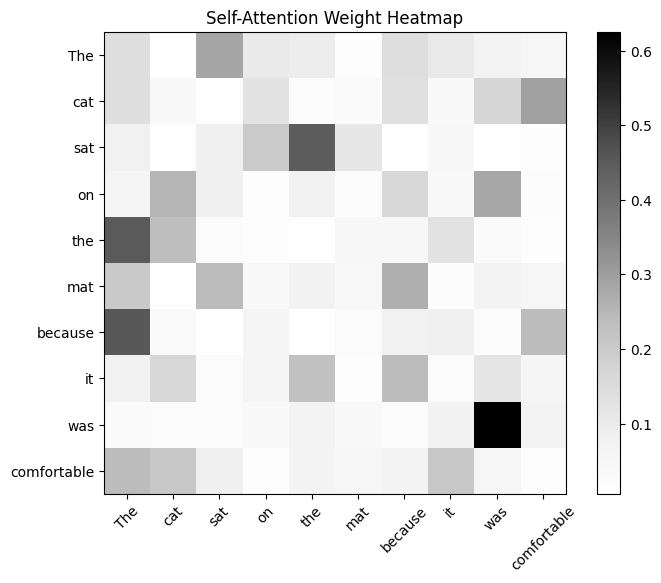

In [2]:
class SelfAttentionLayer:
    def __init__(self, d_model, d_k):
        scale = np.sqrt(2.0 / (d_model + d_k))
        self.W_Q = np.random.randn(d_model, d_k) * scale
        self.W_K = np.random.randn(d_model, d_k) * scale
        self.W_V = np.random.randn(d_model, d_k) * scale

    def forward(self, X):

        Q = X @ self.W_Q
        K = X @ self.W_K
        V = X @ self.W_V
        return scaled_dot_product_attention(Q, K, V)


tokens = ["The", "cat", "sat", "on", "the", "mat", "because", "it", "was", "comfortable"]
seq_len = len(tokens)
d_model, d_k = 128, 64
X = np.random.randn(seq_len, d_model)
layer = SelfAttentionLayer(d_model, d_k)
out, attn_weights = layer.forward(X)

plt.figure(figsize=(8, 6))
plt.imshow(attn_weights, cmap="Greys")
plt.xticks(range(len(tokens)), tokens, rotation=45)
plt.yticks(range(len(tokens)), tokens)
plt.title("Self-Attention Weight Heatmap")
plt.colorbar()
plt.show()

In [ ]:
Q1: Différence avec la cross-attention ?
En self-attention, Q, K, et V viennent de la même source (ex: l'encodeur). En cross-attention, Q vient du décodeur, tandis que K et V viennent de la sortie de l'encodeur.
Q2: Rôle des matrices de poids $W^Q, W^K, W^V$ ?
Elles permettent de projeter les données dans des espaces de représentation différents. Sans elles, le modèle serait figé sur la similarité brute des embeddings et perdrait sa capacité à apprendre des relations complexes (syntaxiques, sémantiques).

In [3]:
class MultiHeadAttention:
    def __init__(self, d_model, num_heads):
        self.h = num_heads
        self.d_k = d_model // num_heads
        self.d_model = d_model

        scale = np.sqrt(2.0 / (d_model + self.d_k))
        self.W_Q = [np.random.randn(d_model, self.d_k) * scale for _ in range(self.h)]
        self.W_K = [np.random.randn(d_model, self.d_k) * scale for _ in range(self.h)]
        self.W_V = [np.random.randn(d_model, self.d_k) * scale for _ in range(self.h)]
        self.W_O = np.random.randn(self.h * self.d_k, d_model) * scale

    def forward(self, Q_in, K_in, V_in, mask=None):
        heads = []
        all_weights = []
        for i in range(self.h):

            head_i, w_i = scaled_dot_product_attention(
                Q_in @ self.W_Q[i], K_in @ self.W_K[i], V_in @ self.W_V[i], mask
            )
            heads.append(head_i)
            all_weights.append(w_i)


        concat = np.concatenate(heads, axis=-1)
        output = concat @ self.W_O
        return output, all_weights

In [ ]:
Q1: Calcul des paramètres ($d_{model}=512, h=8$)?$d_k = 512 / 8 = 64$.Paramètres par tête : $3 \times (512 \times 64)$ ($W^Q, W^K, W^V$).Pour 8 têtes : $8 \times 3 \times 512 \times 64 = 786,432$ paramètres.Projection finale $W^O$ : $(8 \times 64) \times 512 = 512 \times 512 = 262,144$ paramètres.Total : $1,048,576$ paramètres.
Q4: Initialisation aléatoire ?
Elle sert à briser la symétrie. Si toutes les têtes étaient initialisées de la même manière, elles apprendraient toutes exactement les mêmes caractéristiques, rendant l'architecture multi-tête inutile.

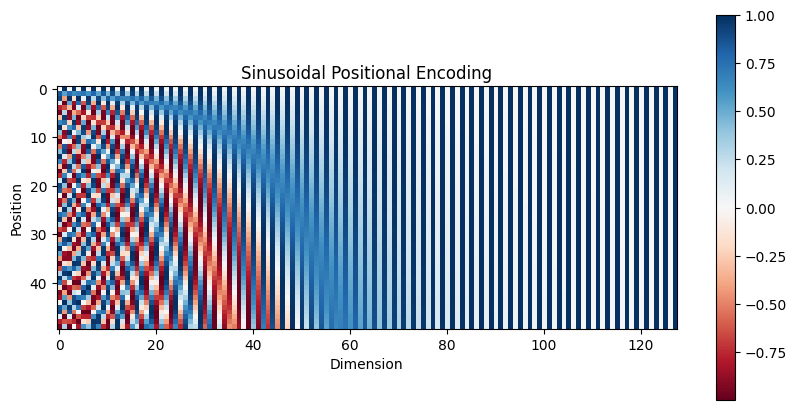

In [4]:
def sinusoidal_positional_encoding(seq_len, d_model):
    PE = np.zeros((seq_len, d_model))
    positions = np.arange(seq_len)[:, np.newaxis]
    div_term = np.power(10000.0, np.arange(0, d_model, 2) / d_model)

    PE[:, 0::2] = np.sin(positions / div_term)
    PE[:, 1::2] = np.cos(positions / div_term)
    return PE


pe = sinusoidal_positional_encoding(50, 128)
plt.figure(figsize=(10, 5))
plt.imshow(pe, cmap="RdBu")
plt.title("Sinusoidal Positional Encoding")
plt.xlabel("Dimension")
plt.ylabel("Position")
plt.colorbar()
plt.show()

In [ ]:
Q2: Quel encodage gère mieux les séquences plus longues que prévu ?
C'est le Sinusoidal Encoding. Étant basé sur des fonctions périodiques fixes, il peut s'extrapoler à des longueurs inconnues, contrairement au Learnable Encoding qui est limité à la taille de sa table apprise pendant l'entraînement.
Q3: Rotary Position Embedding (RoPE) ?
Contrairement aux encodages additifs, RoPE applique une rotation dans l'espace complexe aux queries et keys. Cela permet d'encoder la distance relative entre les tokens directement via le produit scalaire.

In [ ]:
Q1: Pourquoi un masque causal dans le décodeur ?
Il empêche le modèle de "tricher" pendant l'entraînement en regardant les mots futurs qu'il est censé prédire.
Q2: Rôle des connexions résiduelles ?
Elles permettent au gradient de circuler plus facilement dans les réseaux profonds, évitant sa disparition (vanishing gradient).
Q5: Stratégies pour les longs contextes ($n=10000$) ?
Sliding Window Attention (ex: Longformer) : On ne regarde que les voisins proches.
Flash Attention : Optimisation mémoire via un calcul par blocs (tiling).